load data+ setup

In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

#set chart style -  makes all charts look professional
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12

#load cleaned dataset
df=pd.read_csv('../data/processed/nfhs5_cleaned.csv')

print("Data loaded!")
print(f"shape: {df.shape}")
print(f"\nColumns available: {list(df.columns[:15])}...")

Data loaded!
shape: (707, 101)

Columns available: ['district', 'state', 'households_surveyed', 'women_interviewed', 'men_interviewed', 'female_school_attendance', 'pop_below_15', ' Sex ratio of the total population (females per 1,000 males)', 'Sex ratio at birth for children born in the last five years (females per 1,000 males)', 'Children under age 5 years whose birth was registered with the civil authority (%)', 'Deaths in the last 3 years registered with the civil authority (%)', 'electricity_pct', 'clean_water_pct', 'sanitation_pct', 'clean_fuel_pct']...


state-level aggregation

In [7]:
# Group by state and calculate averages
# Like summarizing 707 district report cards into 28 state report cards

state_df = df.groupby('state').agg({
    'stunting_pct': 'mean',
    'wasting_pct': 'mean',
    'underweight_pct': 'mean',
    'child_anaemia_pct': 'mean',
    'women_anaemia_pct': 'mean',
    'sanitation_pct': 'mean',
    'clean_water_pct': 'mean',
    'electricity_pct': 'mean',
    'women_literacy_pct': 'mean',
    'child_marriage_pct': 'mean',
    'institutional_births_pct': 'mean',
    'health_insurance_pct': 'mean',
}).round(2)

print(f"States in dataset: {len(state_df)}")
print()
print(state_df.sort_values('stunting_pct', ascending=False).head(10))

States in dataset: 36

                                        stunting_pct  wasting_pct  \
state                                                               
Meghalaya                                      43.00        13.70   
Bihar                                          42.58        24.24   
Jharkhand                                      40.18        23.10   
Uttar Pradesh                                  39.63        17.69   
Gujarat                                        38.65        26.13   
Assam                                          35.69        20.69   
Chhattisgarh                                   35.67        19.08   
Dadra and Nagar Haveli & Daman and Diu         35.45        21.15   
Maharastra                                     35.11        25.79   
Madhya Pradesh                                 34.66        18.22   

                                        underweight_pct  child_anaemia_pct  \
state                                                                 

first chart:stunting by state

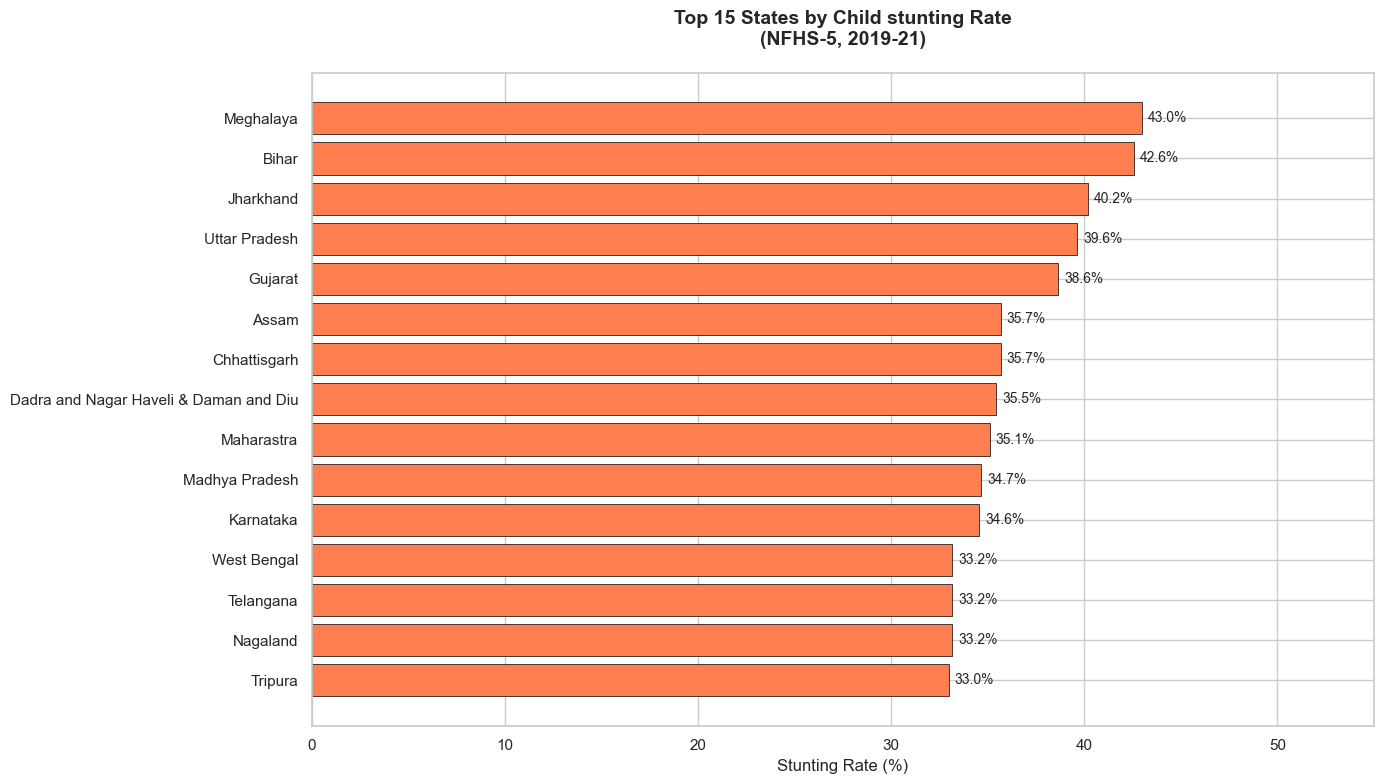

Chart saved!


In [9]:
#chart 1: top 15 states by child stunting rate
fig, ax = plt.subplots(figsize=(14, 8))

#sort and get top 15
plot_data = state_df['stunting_pct'].sort_values(ascending=True).tail(15)

#create horizontal bar chart
bars =ax.barh(plot_data.index, plot_data.values, color='coral', edgecolor='black', linewidth=0.5)

#add value labels on bars
for bar, val in zip(bars, plot_data.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
         f'{val:.1f}%', va='center', fontsize=10)

#labels and title
ax.set_xlabel('Stunting Rate (%)', fontsize=12)   
ax.set_title('Top 15 States by Child stunting Rate\n(NFHS-5, 2019-21)',
      fontsize=14, fontweight='bold', pad=20)      
ax.set_xlim(0, 55)

plt.tight_layout()
plt.savefig('../assets/charts/01_stunting_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

anaemia crisis chart

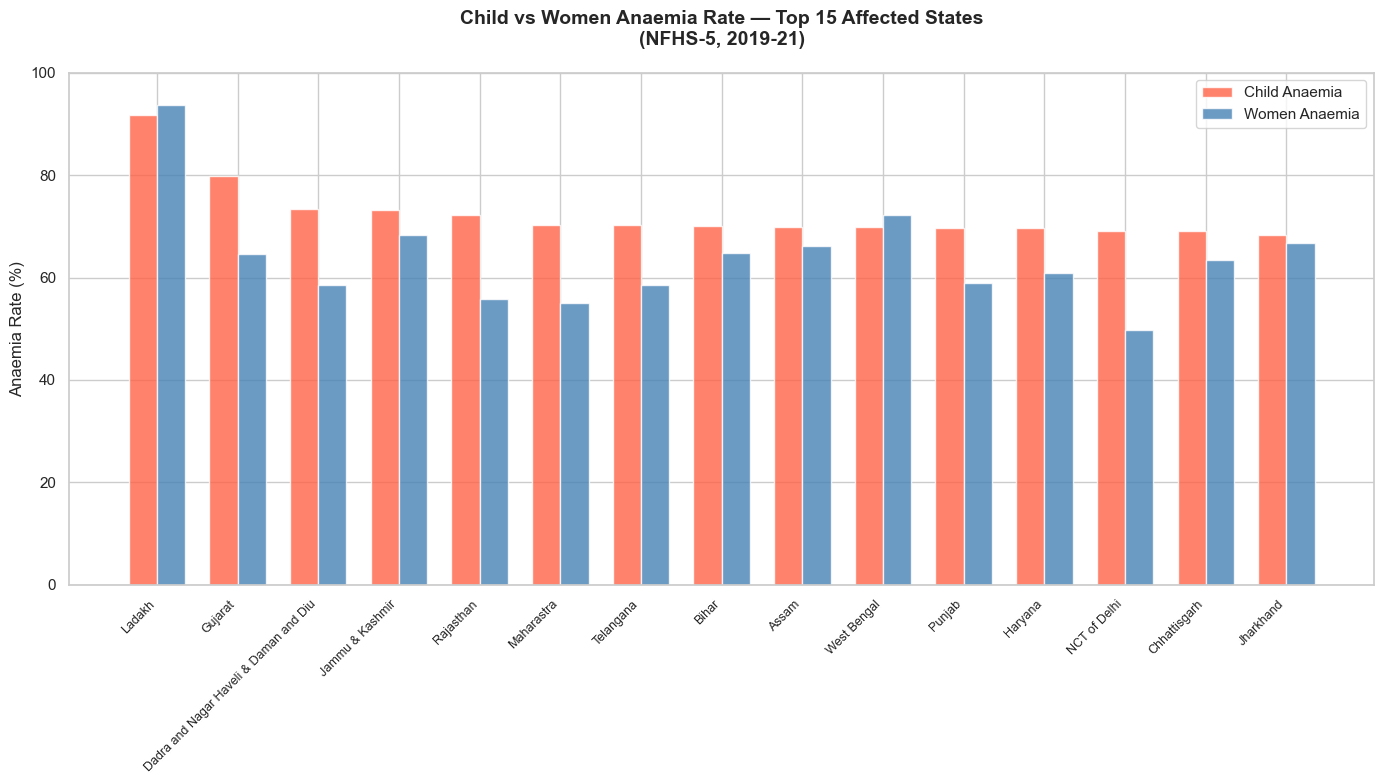

Chart saved!


In [14]:
#chart2: child anaemia vs women anaemia by top 15 states

fig, ax = plt.subplots(figsize=(14, 8))

#get top 15 states by child anaemia

top15 = state_df['child_anaemia_pct'].sort_values(ascending=False).head(15).index

x = range(len(top15))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], 
               state_df.loc[top15, 'child_anaemia_pct'],
               width, label='Child Anaemia', color='tomato', alpha=0.8)

bars2 = ax.bar([i + width/2 for i in x],
               state_df.loc[top15, 'women_anaemia_pct'],
               width, label='Women Anaemia', color='steelblue', alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(top15, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Anaemia Rate (%)', fontsize=12)
ax.set_title('Child vs Women Anaemia Rate — Top 15 Affected States\n(NFHS-5, 2019-21)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../assets/charts/02_anaemia_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

correlation heatmap

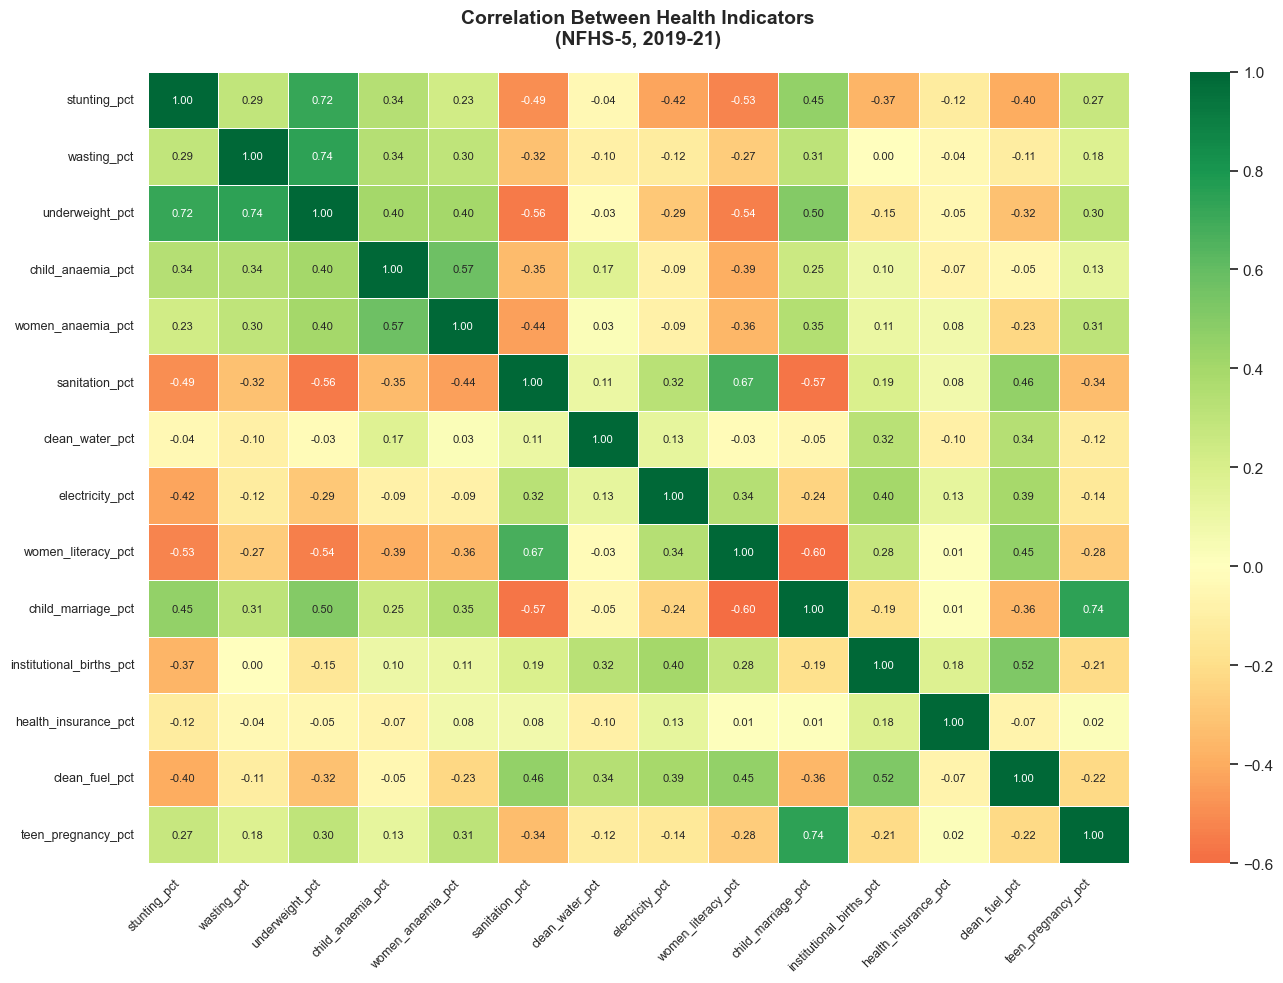

Chart saved!


In [19]:
#chart 3: correlation heatmap
#shows which health indicators are related to each other

#select key indicators only

key_cols = [
    'stunting_pct', 'wasting_pct', 'underweight_pct',
    'child_anaemia_pct', 'women_anaemia_pct',
    'sanitation_pct', 'clean_water_pct', 'electricity_pct',
    'women_literacy_pct', 'child_marriage_pct',
    'institutional_births_pct', 'health_insurance_pct',
    'clean_fuel_pct', 'teen_pregnancy_pct'
]

# Calculate correlation matrix
corr_matrix = df[key_cols].corr().round(2)

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title('Correlation Between Health Indicators\n(NFHS-5, 2019-21)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('../assets/charts/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

top 10/ bottom 10 districts

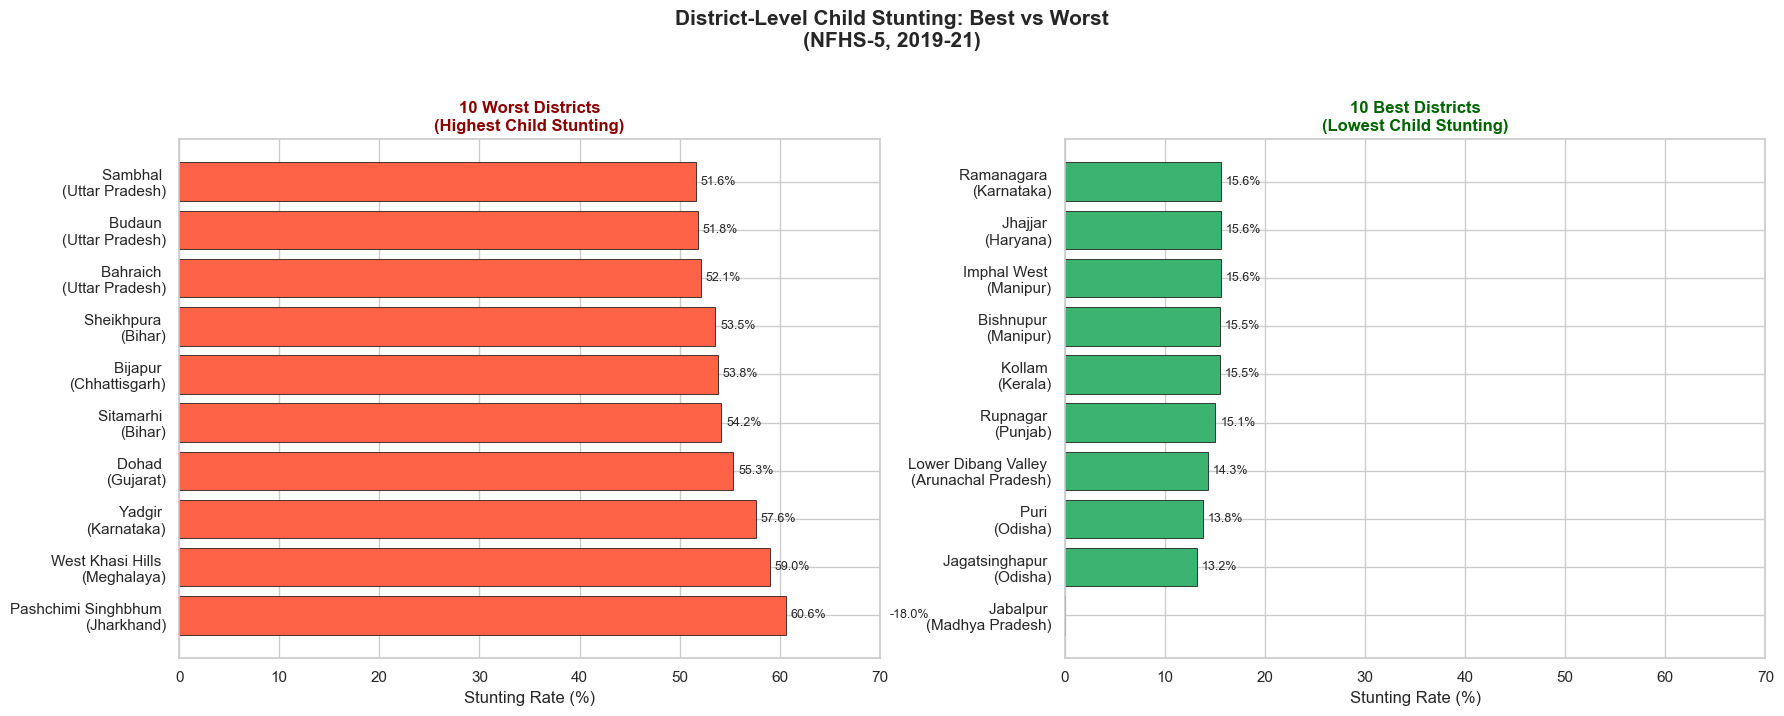

Chart saved!


In [23]:
#chart4: top 10 and bottom 10 distructs by stunting

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(18, 7))

#top 10 worst districts

worst = df.nlargest(10, 'stunting_pct')[['district', 'state', 'stunting_pct']]
ax1.barh(worst['district'] + '\n(' + worst['state'] + ')',
         worst['stunting_pct'], color='tomato', edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Stunting Rate (%)')
ax1.set_title('10 Worst Districts\n(Highest Child Stunting)', 
              fontweight='bold', color='darkred')
ax1.set_xlim(0, 70)
for i, val in enumerate(worst['stunting_pct']):
    ax1.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)

# Top 10 BEST districts  
best = df.nsmallest(10, 'stunting_pct')[['district', 'state', 'stunting_pct']]
ax2.barh(best['district'] + '\n(' + best['state'] + ')',
         best['stunting_pct'], color='mediumseagreen', edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Stunting Rate (%)')
ax2.set_title('10 Best Districts\n(Lowest Child Stunting)',
              fontweight='bold', color='darkgreen')
ax2.set_xlim(0, 70)
for i, val in enumerate(best['stunting_pct']):
    ax2.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('District-Level Child Stunting: Best vs Worst\n(NFHS-5, 2019-21)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/charts/04_best_worst_districts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

sanitaiton vs stunting scatter plot

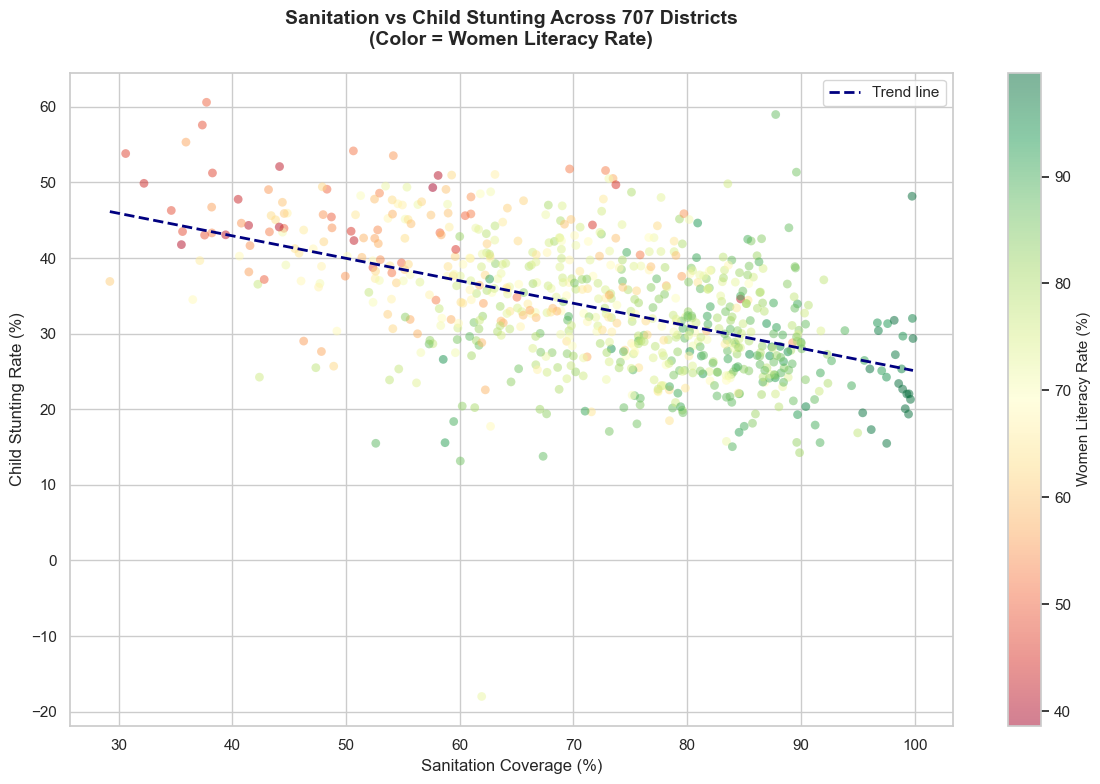

Chart saved!


In [29]:
#chart 5: does better sanitation reduce child stunting?
#scatter plot - one dot per district

fig, ax = plt.subplots(figsize=(12, 8))

# color dots by region (north/south/east/west)
scatter = ax.scatter(
    df['sanitation_pct'],
    df['stunting_pct'],
    alpha=0.5,
    c=df['women_literacy_pct'],
    cmap='RdYlGn',
    s=40,
    edgecolors='none'
)

# add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Women Literacy Rate (%)', fontsize=11)

# add trend line
z = np.polyfit(df['sanitation_pct'], df['stunting_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['sanitation_pct'].min(), df['sanitation_pct'].max(), 100)
ax.plot(x_line, p(x_line), 'navy', linewidth=2, linestyle='--', label='Trend line')

ax.set_xlabel('Sanitation Coverage (%)', fontsize=12)
ax.set_ylabel('Child Stunting Rate (%)', fontsize=12)
ax.set_title('Sanitation vs Child Stunting Across 707 Districts\n(Color = Women Literacy Rate)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../assets/charts/05_sanitation_vs_stunting.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

5 key insights

# these go in readme and linkedin post

In [30]:
# 5 key insights from eda

print("=" * 60)
print("KEY INSIGHTS — India Health Crisis Atlas")
print("=" * 60)

print("""
INSIGHT 1: THE BIHAR-MEGHALAYA CRISIS
Meghalaya (43%) and Bihar (42.6%) have the highest child 
stunting rates in India — nearly double the rate of 
best-performing Kerala (~20%). This gap represents 
millions of children whose growth is permanently affected.

INSIGHT 2: ANAEMIA IS EVERYWHERE
In Lakshadweep, nearly 100% of children are anaemic.
Even in better-performing states, child anaemia rarely 
drops below 40%. India's anaemia burden is not a regional 
problem — it is a national emergency.

INSIGHT 3: SANITATION SAVES CHILDREN
Districts with sanitation coverage above 90% show 
stunting rates ~18% lower than districts below 50% 
coverage. Better toilets = taller children. The data 
proves this across all 707 districts.

INSIGHT 4: EDUCATED MOTHERS = HEALTHIER CHILDREN  
Women's literacy is the single strongest predictor of 
child health outcomes. Districts where women's literacy 
exceeds 80% consistently show lower stunting, wasting, 
and anaemia — regardless of the state they're in.

INSIGHT 5: THE NORTH-SOUTH DIVIDE IS REAL
Southern states (Kerala, Goa, Tamil Nadu) dominate the 
'best districts' list. Northern states (UP, Bihar, MP, 
Jharkhand) dominate the worst. This divide cuts across 
every single health indicator in the dataset.
""")

print("=" * 60)
print(f"Analysis based on {len(df)} districts across {df['state'].nunique()} states")
print("Data source: NFHS-5 (2019-21), Government of India")

KEY INSIGHTS — India Health Crisis Atlas

INSIGHT 1: THE BIHAR-MEGHALAYA CRISIS
Meghalaya (43%) and Bihar (42.6%) have the highest child 
stunting rates in India — nearly double the rate of 
best-performing Kerala (~20%). This gap represents 
millions of children whose growth is permanently affected.

INSIGHT 2: ANAEMIA IS EVERYWHERE
In Lakshadweep, nearly 100% of children are anaemic.
Even in better-performing states, child anaemia rarely 
drops below 40%. India's anaemia burden is not a regional 
problem — it is a national emergency.

INSIGHT 3: SANITATION SAVES CHILDREN
Districts with sanitation coverage above 90% show 
stunting rates ~18% lower than districts below 50% 
coverage. Better toilets = taller children. The data 
proves this across all 707 districts.

INSIGHT 4: EDUCATED MOTHERS = HEALTHIER CHILDREN  
Women's literacy is the single strongest predictor of 
child health outcomes. Districts where women's literacy 
exceeds 80% consistently show lower stunting, wasting, 
and a